# Women's Clothing Reviews Sentiment Analysis
### Complete EDA & Modeling Pipeline
### Explanation:
This notebook focuses on analyzing reviews of women's clothing products. The goal is to predict the sentiment (Positive, Neutral, Negative) of each review using machine learning. It covers:

- EDA (Exploratory Data Analysis): Understanding data distributions, patterns, and missing values.

- Text preprocessing: Cleaning reviews for modeling.

- Modeling: Training and evaluating multiple machine learning algorithms.

- Visualization & Insights: Visualizing sentiment patterns, word clouds, and feature importance.

- Deployment-ready outputs: Saving trained models and preprocessing objects.

### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                           confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

[nltk_data] Downloading package stopwords to C:\Users\Zafar
[nltk_data]     Nadeem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Zafar
[nltk_data]     Nadeem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Zafar
[nltk_data]     Nadeem\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 2. Load Dataset

In [2]:

# Load the dataset
df = pd.read_csv('../data/raw/Womens Clothing E-Commerce Reviews.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (23486, 11)

First 5 rows:


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [3]:
# Check column names and data types
print("Column Info:")
df.info()

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [4]:
# Check for missing values
print("Missing Values:")
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                 Missing Count  Missing %
Title                     3810  16.222430
Review Text                845   3.597888
Division Name               14   0.059610
Department Name             14   0.059610
Class Name                  14   0.059610


In [5]:
# Basic statistics of numerical columns
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


### 3. Data Preprocessing

In [6]:
# Drop unnecessary columns
df_clean = df.drop(['Unnamed: 0'], axis=1, errors='ignore')

# Rename columns for easier access
df_clean.columns = ['clothing_id', 'age', 'title', 'review_text', 'rating', 
                   'recommended', 'positive_feedback', 'division_name', 
                   'department_name', 'class_name']

# Create sentiment labels based on rating
def create_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df_clean['sentiment'] = df_clean['rating'].apply(create_sentiment)





In [7]:
# Handle missing values in review text
print(f"Missing reviews before: {df_clean['review_text'].isnull().sum()}")
df_clean = df_clean.dropna(subset=['review_text'])
print(f"Missing reviews after: {df_clean['review_text'].isnull().sum()}")

# Fill missing titles with empty string
df_clean['title'] = df_clean['title'].fillna('')

# Create combined text feature (title + review)
df_clean['full_text'] = df_clean['title'] + ' ' + df_clean['review_text']


Missing reviews before: 845
Missing reviews after: 0


### 4. Exploratory Data Analysis


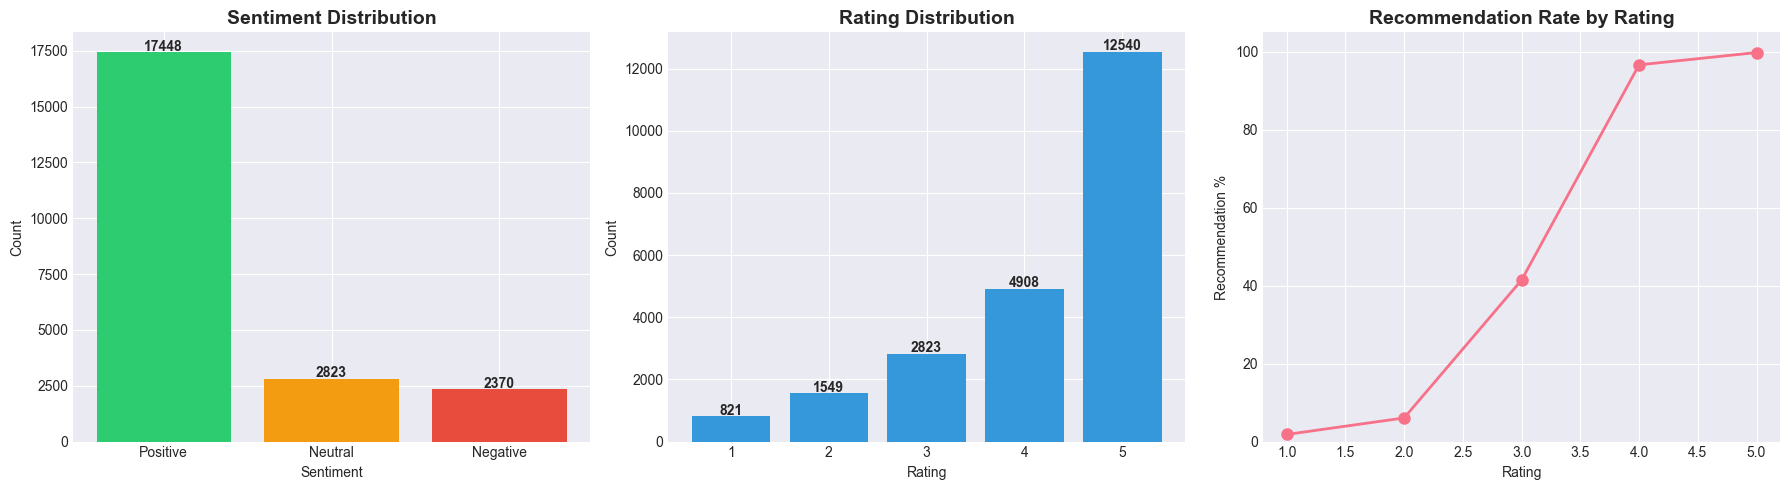

In [8]:
# Sentiment Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sentiment count
sentiment_counts = df_clean['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Rating distribution
rating_counts = df_clean['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='#3498db')
axes[1].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[1].text(rating_counts.index[i], v + 50, str(v), ha='center', fontweight='bold')

# 3. Recommendation vs Rating
recommend_by_rating = df_clean.groupby('rating')['recommended'].mean() * 100
axes[2].plot(recommend_by_rating.index, recommend_by_rating.values, marker='o', linewidth=2, markersize=8)
axes[2].set_title('Recommendation Rate by Rating', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Recommendation %')
axes[2].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('../models/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


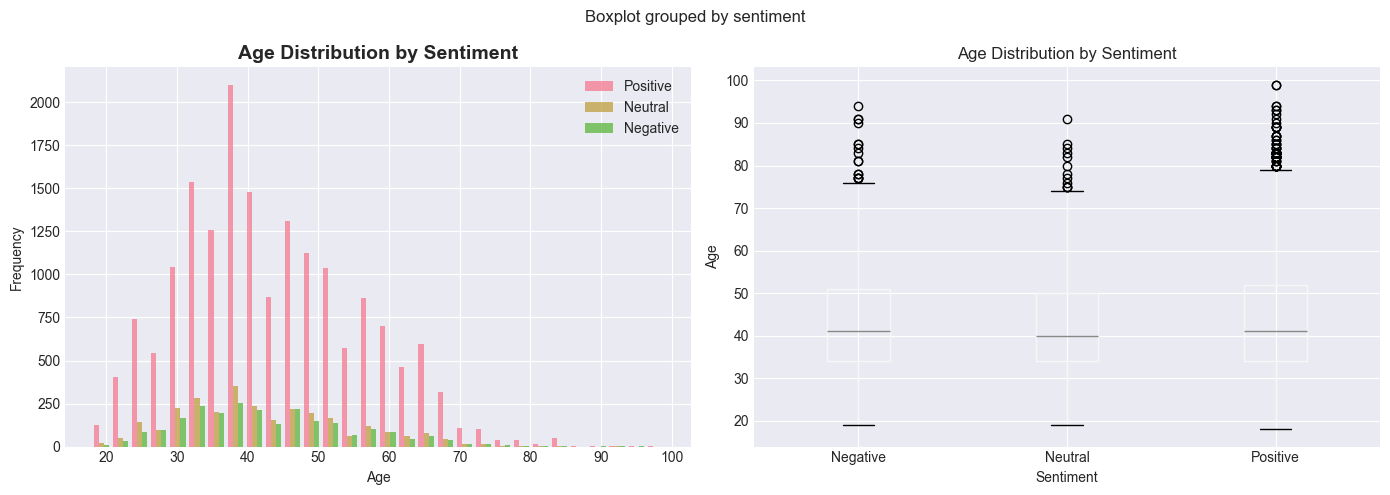

In [9]:
# Age distribution by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist([df_clean[df_clean['sentiment'] == 'Positive']['age'],
              df_clean[df_clean['sentiment'] == 'Neutral']['age'],
              df_clean[df_clean['sentiment'] == 'Negative']['age']],
             label=['Positive', 'Neutral', 'Negative'], bins=30, alpha=0.7)
axes[0].set_title('Age Distribution by Sentiment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
df_clean.boxplot(column='age', by='sentiment', ax=axes[1])
axes[1].set_title('Age Distribution by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()


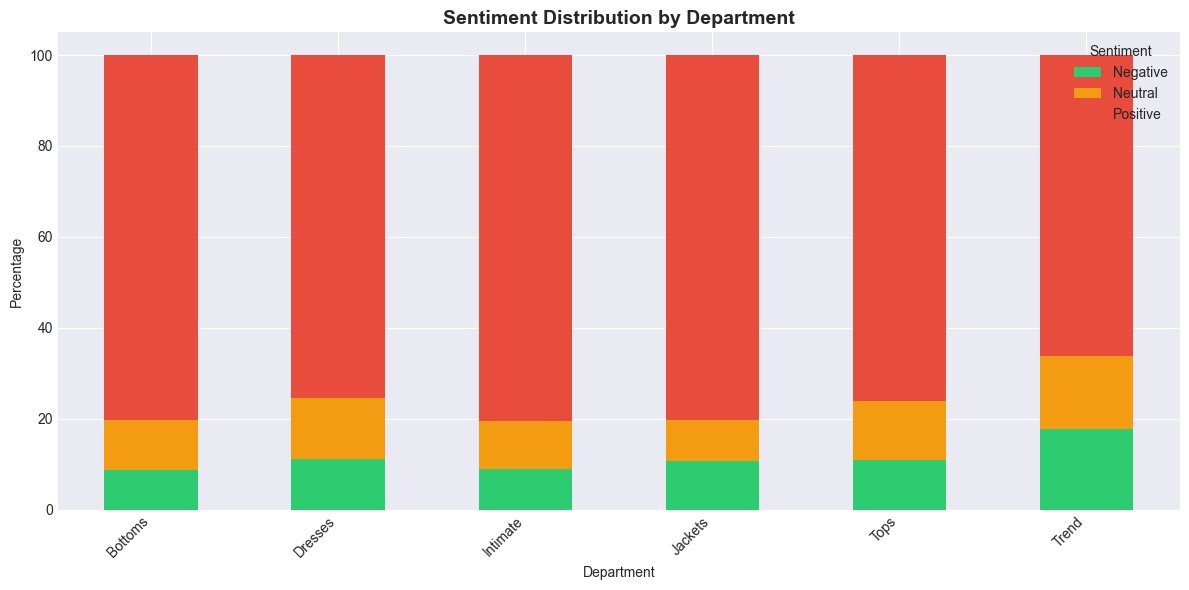

In [10]:
# Department analysis
dept_sentiment = pd.crosstab(df_clean['department_name'], df_clean['sentiment'], normalize='index') * 100
dept_sentiment.plot(kind='bar', stacked=True, figsize=(12, 6), 
                    color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Sentiment Distribution by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Percentage')
plt.legend(title='Sentiment')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 5. Text Analysis & Word Clouds

In [11]:
# Text preprocessing function for visualization
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply preprocessing
df_clean['processed_text'] = df_clean['review_text'].fillna('').apply(preprocess_text)

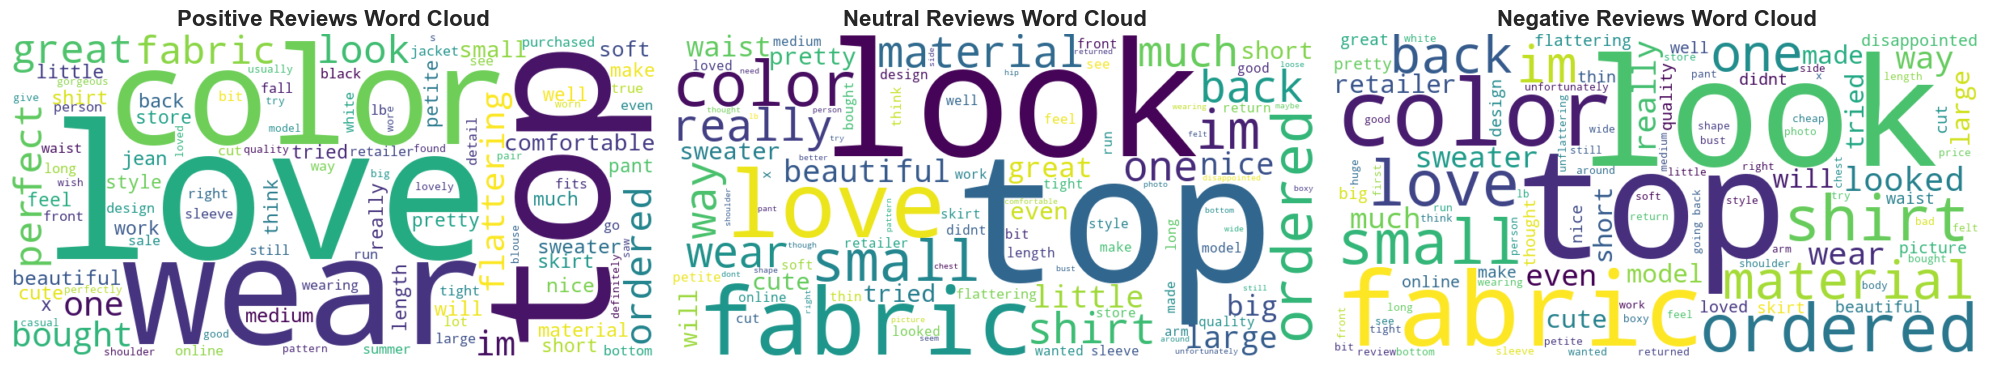

In [12]:
# Generate word clouds for each sentiment
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

stopwords_custom = set(STOPWORDS)
stopwords_custom.update(['dress', 'size', 'fit', 'like', 'just', 'got', 'get'])

for idx, sentiment in enumerate(['Positive', 'Neutral', 'Negative']):
    text = ' '.join(df_clean[df_clean['sentiment'] == sentiment]['processed_text'])
    
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         stopwords=stopwords_custom,
                         max_words=100,
                         colormap='viridis',
                         contour_width=1,
                         contour_color='steelblue').generate(text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{sentiment} Reviews Word Cloud', fontsize=16, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../models/wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

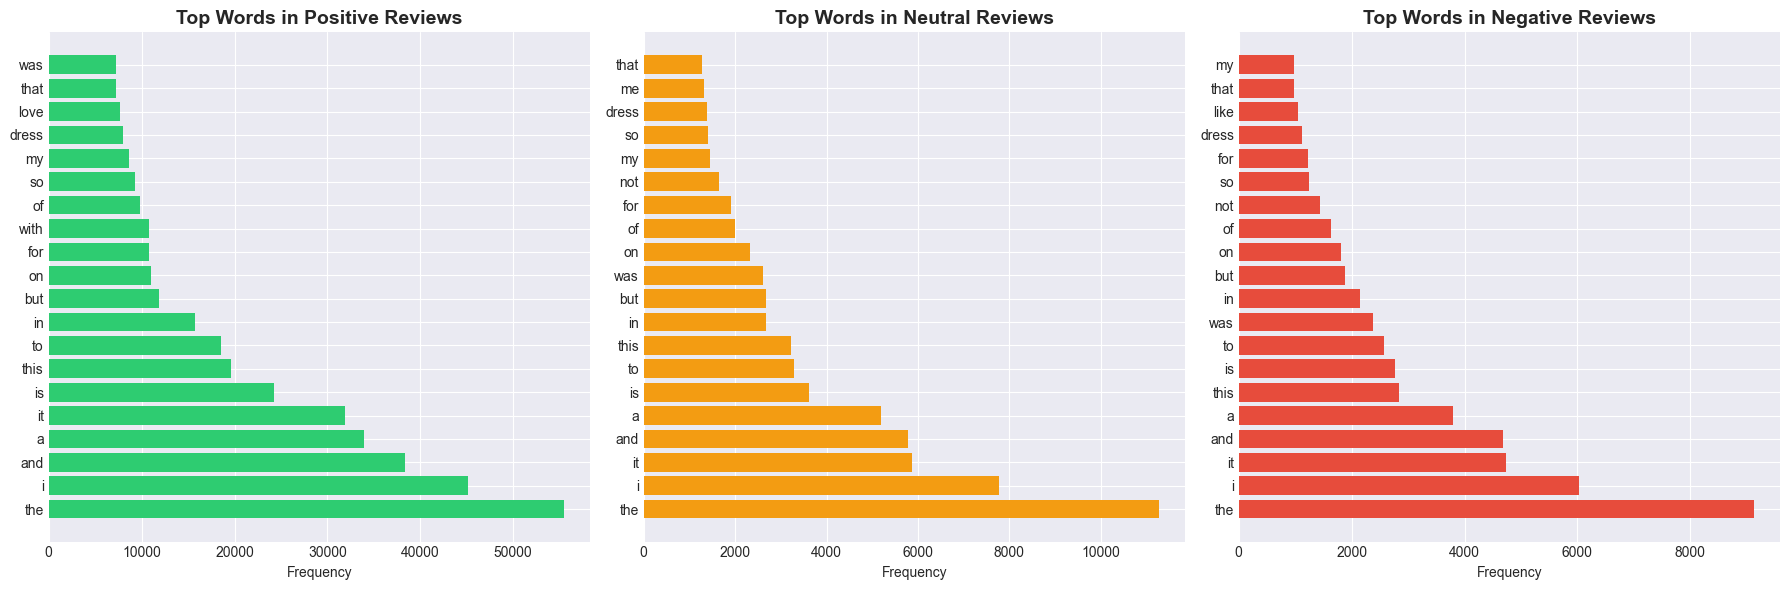

In [13]:
# Top words analysis
def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    word_freq = Counter(all_words)
    most_common = word_freq.most_common(n)
    
    words, counts = zip(*most_common)
    return words, counts

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(['Positive', 'Neutral', 'Negative']):
    words, counts = get_top_words(df_clean[df_clean['sentiment'] == sentiment]['processed_text'])
    
    axes[idx].barh(words, counts, color=['#2ecc71', '#f39c12', '#e74c3c'][idx])
    axes[idx].set_title(f'Top Words in {sentiment} Reviews', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


### 6. Advanced Text Preprocessing for Modeling

In [14]:
# Initialize stemmer and stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text_for_model(text):
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Tokenize and remove stopwords, then stem
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words and len(word) > 2]
    
    return ' '.join(words)

# Apply advanced cleaning
df_clean['clean_text'] = df_clean['review_text'].apply(clean_text_for_model)

# Remove empty reviews after cleaning
df_clean = df_clean[df_clean['clean_text'].str.len() > 0]

print(f"Final dataset shape: {df_clean.shape}")
print(f"Sentiment distribution:\n{df_clean['sentiment'].value_counts()}")



Final dataset shape: (22641, 14)
Sentiment distribution:
sentiment
Positive    17448
Neutral      2823
Negative     2370
Name: count, dtype: int64


 
## 7. Train-Test Split


In [15]:
# Prepare features and target
X = df_clean['clean_text']
y = df_clean['sentiment']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set distribution:\n{y_train.value_counts(normalize=True)}")


Training set size: 18112
Test set size: 4529

Training set distribution:
sentiment
Positive    0.770649
Neutral     0.124669
Negative    0.104682
Name: proportion, dtype: float64


### 8.  Feature Extraction with TF-IDF

In [16]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit and transform training data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")


TF-IDF matrix shape: (18112, 5000)


### 9. Model Training and Comparison

In [17]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_train_tfidf, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_tfidf)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))



Training Logistic Regression...
Accuracy: 0.8205

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.44      0.51       474
     Neutral       0.43      0.22      0.29       565
    Positive       0.87      0.97      0.92      3490

    accuracy                           0.82      4529
   macro avg       0.64      0.54      0.57      4529
weighted avg       0.79      0.82      0.80      4529


Training Naive Bayes...
Accuracy: 0.7947

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.19      0.30       474
     Neutral       0.42      0.07      0.13       565
    Positive       0.80      0.99      0.89      3490

    accuracy                           0.79      4529
   macro avg       0.67      0.42      0.44      4529
weighted avg       0.75      0.79      0.73      4529


Training Linear SVM...
Accuracy: 0.8161

Classification Report:
              precision    recall

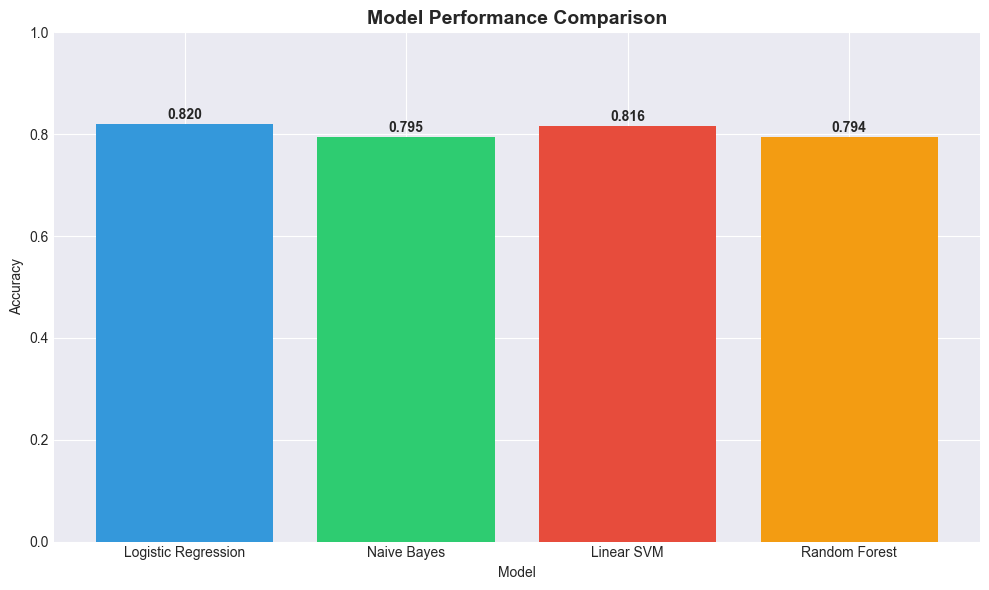

In [18]:
# Compare model performance
plt.figure(figsize=(10, 6))
models_list = list(results.keys())
accuracies = list(results.values())

bars = plt.bar(models_list, accuracies, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim([0, 1])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 10. Best Model Evaluation (Logistic Regression)

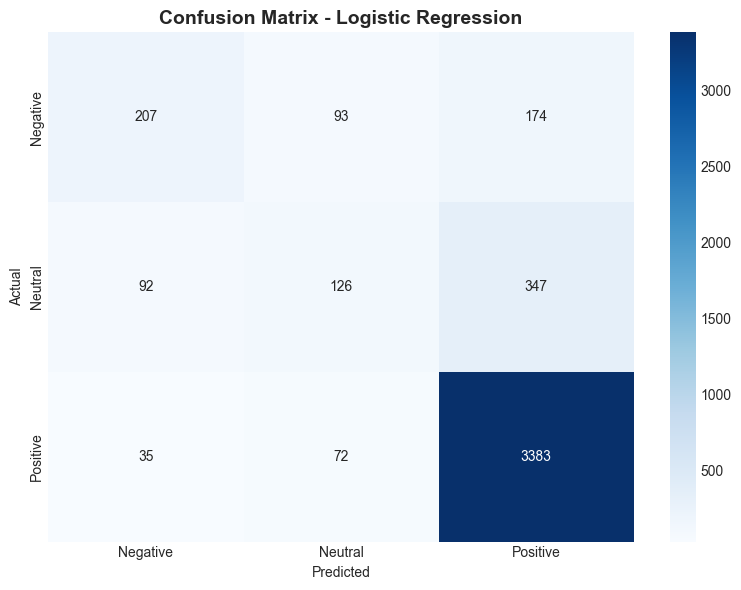

In [20]:

# Get best model (Logistic Regression)
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_tfidf, y_train)
y_pred = best_model.predict(X_test_tfidf)
y_pred_proba = best_model.predict_proba(X_test_tfidf)

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()



### 10.2. Detailed classification report

In [21]:
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# Cross-validation score
cv_scores = cross_val_score(best_model, X_train_tfidf, y_train, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Average CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.44      0.51       474
     Neutral       0.43      0.22      0.29       565
    Positive       0.87      0.97      0.92      3490

    accuracy                           0.82      4529
   macro avg       0.64      0.54      0.57      4529
weighted avg       0.79      0.82      0.80      4529


Cross-validation scores: [0.82473089 0.8230748  0.81722805 0.82247377 0.8186085 ]
Average CV score: 0.8212 (+/- 0.0057)


### 11. Feature Importance Analysis

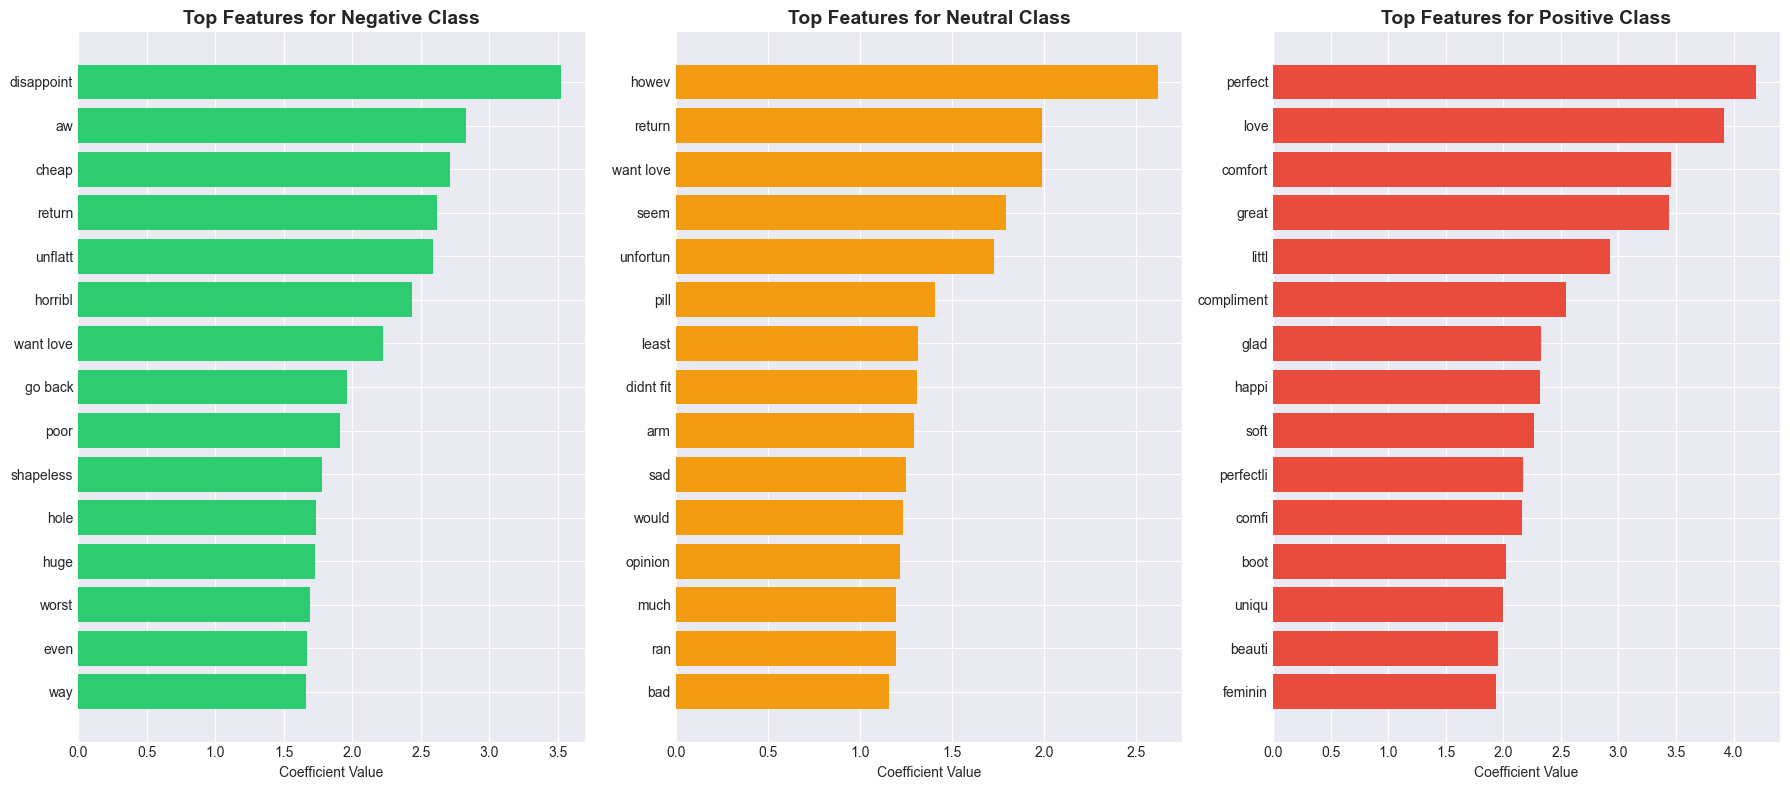

In [23]:
# Get feature importance from logistic regression
feature_names = tfidf.get_feature_names_out()
coefs = best_model.coef_

# For each class, get top features
classes = best_model.classes_
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, class_name in enumerate(classes):
    class_coefs = coefs[idx]
    top_indices = np.argsort(class_coefs)[-15:]
    top_features = [feature_names[i] for i in top_indices]
    top_scores = class_coefs[top_indices]
    
    axes[idx].barh(top_features, top_scores, color=['#2ecc71', '#f39c12', '#e74c3c'][idx])
    axes[idx].set_title(f'Top Features for {class_name} Class', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


 ### 12. Save Models and Preprocessors

In [24]:

import pickle
import json

# Save the model
with open('../models/logistic_regression.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the TF-IDF vectorizer
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save model metrics
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'classes': classes.tolist()
}

with open('../models/model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("Models and metrics saved successfully!")


Models and metrics saved successfully!


 ### 13. Test with Sample Reviews

In [25]:

# Test the model with custom reviews
sample_reviews = [
    "I absolutely love this dress! The fabric is amazing and fits perfectly.",
    "The quality is terrible, it fell apart after first wash. Very disappointed.",
    "It's okay, not great but not bad either. Does the job.",
    "Beautiful design and excellent quality! Will buy again.",
    "The size runs too small, had to return it. Very frustrating experience.",
    "Average product, nothing special but works as expected."
]

print("Sample Review Predictions:")
print("-" * 50)

for review in sample_reviews:
    # Clean and transform
    cleaned = clean_text_for_model(review)
    vectorized = tfidf.transform([cleaned])
    
    # Predict
    prediction = best_model.predict(vectorized)[0]
    probabilities = best_model.predict_proba(vectorized)[0]
    
    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {prediction}")
    print(f"Confidence: Positive: {probabilities[2]:.2f}, Neutral: {probabilities[1]:.2f}, Negative: {probabilities[0]:.2f}")


Sample Review Predictions:
--------------------------------------------------

Review: I absolutely love this dress! The fabric is amazing and fits perfectly.
Predicted Sentiment: Positive
Confidence: Positive: 0.99, Neutral: 0.01, Negative: 0.00

Review: The quality is terrible, it fell apart after first wash. Very disappointed.
Predicted Sentiment: Negative
Confidence: Positive: 0.01, Neutral: 0.13, Negative: 0.85

Review: It's okay, not great but not bad either. Does the job.
Predicted Sentiment: Positive
Confidence: Positive: 0.40, Neutral: 0.30, Negative: 0.30

Review: Beautiful design and excellent quality! Will buy again.
Predicted Sentiment: Positive
Confidence: Positive: 0.85, Neutral: 0.08, Negative: 0.07

Review: The size runs too small, had to return it. Very frustrating experience.
Predicted Sentiment: Positive
Confidence: Positive: 0.40, Neutral: 0.34, Negative: 0.26

Review: Average product, nothing special but works as expected.
Predicted Sentiment: Neutral
Confidence: 